# Approach 1 — Version 3: SVM + TF-IDF with Preprocessing + Random Masking

Builds on the **baseline** model (LinearSVC) and adds:

| Addition | From |
|---|---|
| Teen code normalization | Improved version |
| Multi-label augmentation | Improved version |
| Handcrafted features | Improved version |
| **Random token masking** | New in V3 |

Does **not** include LogisticRegression or per-class threshold tuning (those are V4).

**Prerequisite:** Run `data_preparation/data_split.ipynb` first.

In [1]:
#!pip install scikit-learn scikit-multilearn scipy numpy pandas matplotlib seaborn joblib --quiet

In [2]:
import json
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.sparse as sp
from scipy.sparse import hstack, vstack as sp_vstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    f1_score, hamming_loss, accuracy_score, classification_report
)

warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)

DATA_DIR = '../final_data'

## 1. Load Pre-split Data

In [3]:
def load_jsonl(path):
    texts, labels = [], []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            texts.append(item['text'])
            labels.append(item['cats'])
    return texts, labels

train_texts, train_labels = load_jsonl(f'{DATA_DIR}/train.jsonl')
val_texts,   val_labels   = load_jsonl(f'{DATA_DIR}/val.jsonl')
test_texts,  test_labels  = load_jsonl(f'{DATA_DIR}/test.jsonl')

mlb    = joblib.load(f'{DATA_DIR}/mlb.joblib')
y_train = mlb.transform(train_labels)
y_val   = mlb.transform(val_labels)
y_test  = mlb.transform(test_labels)

print(f'Train : {len(train_texts):4d} samples')
print(f'Val   : {len(val_texts):4d} samples')
print(f'Test  : {len(test_texts):4d} samples')
print(f'Labels: {len(mlb.classes_)} classes')

Train : 3605 samples
Val   :  454 samples
Test  :  450 samples
Labels: 32 classes


## 2. Teen Code Normalization

Converts informal abbreviations to standard Vietnamese before TF-IDF.  
English tokens (brand names) are protected from substitution.

In [4]:
TEEN_CODE = {
    'k'   : 'không', 'ko'  : 'không', 'kh' : 'không',
    'khum': 'không', 'kum' : 'không',
    'đc'  : 'được',  'dc'  : 'được',
    'vs'  : 'với',
    'b'   : 'bạn',
    'sốp' : 'shop',  'sốc' : 'shop',
    'ck'  : 'chuyển khoản',
    'r'   : 'rồi',   'rui' : 'rồi',
    'nha' : 'nhé',   'nhen': 'nhé',
    'sp'  : 'sản phẩm',
    'mn'  : 'mọi người',
    'e'   : 'em',    'a'   : 'anh',
    'v'   : 'vậy',  'z' :   'vậy',
    'dchi' : 'địa chỉ',
    'q'     : 'quận', 'tp'   : 'thành phố'
}

def normalize(text):
    text = text.lower()
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    tokens = text.split()
    result = []
    for token in tokens:
        if re.match(r'^[a-z0-9\-]+$', token) and token not in TEEN_CODE:
            result.append(token)
        else:
            result.append(TEEN_CODE.get(token, token))
    return ' '.join(result)

norm_train = [normalize(t) for t in train_texts]
norm_val   = [normalize(t) for t in val_texts]
norm_test  = [normalize(t) for t in test_texts]
print('Normalization applied.')

Normalization applied.


## 3. Multi-label Augmentation

Duplicates multi-label training samples 2× to give the model more signal for co-occurring intents.  
Applied to the **training set only**.

In [5]:
multi_idx    = [i for i, l in enumerate(train_labels) if len(l) > 1]
extra_texts  = [norm_train[i]  for i in multi_idx] * 2
extra_labels = [train_labels[i] for i in multi_idx] * 2

aug_texts  = norm_train + extra_texts
aug_labels = train_labels + extra_labels

print(f'Original train : {len(norm_train)}')
print(f'Multi-label    : {len(multi_idx)}')
print(f'Augmented total: {len(aug_texts)}')

Original train : 3605
Multi-label    : 387
Augmented total: 4379


## 4. Random Token Masking

Randomly drops tokens from each training sample with probability `mask_prob=0.15`.  
Creates one masked copy of the full augmented training set, then concatenates it with the originals.

**Why:** Forces the model to predict intent from partial context, reducing over-reliance on specific trigger words and improving generalisation — analogous to dropout in neural networks.

**Applied to training only** — val and test texts are never masked.

In [6]:
MASK_PROB = 0.15

def random_mask(text: str, mask_prob: float = MASK_PROB, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    tokens = text.split()
    kept = [t for t in tokens if rng.random() > mask_prob]
    return ' '.join(kept) if kept else text  # never return empty string

# Create one masked copy of augmented training set
rng = np.random.default_rng(42)
masked_texts = [random_mask(t, rng=rng) for t in aug_texts]

masked_train_texts  = aug_texts + masked_texts
masked_train_labels = aug_labels + aug_labels  # same labels for masked copies
y_masked = mlb.transform(masked_train_labels)

print(f'Augmented train : {len(aug_texts)}')
print(f'After masking   : {len(masked_train_texts)} (1 masked copy added)')

# Example
original = aug_texts[0]
masked   = masked_texts[0]
print(f'\nExample:')
print(f'  Original: {original}')
print(f'  Masked  : {masked}')

Augmented train : 4379
After masking   : 8758 (1 masked copy added)

Example:
  Original: chị ưu tiên gửi batch mới nhất giúp em.
  Masked  : chị ưu tiên gửi mới nhất giúp


## 5. Feature Extraction

Three feature groups combined via `scipy.sparse.hstack`:

| Group | Description |
|---|---|
| Word TF-IDF (1,2)-gram | Word-level and phrase patterns |
| Char TF-IDF (2,4)-gram | Subword patterns, captures informal tokens |
| Handcrafted features | Message-level signals (length, digits, politeness) |

In [7]:
def handcrafted_features(texts):
    rows = []
    for t in texts:
        rows.append([
            len(t.split()),
            len(t),
            t.count('?'),
            int(bool(re.search(r'0[3-9]\d{8}', t))),
            int(bool(re.search(r'\d+', t))),
            int('\u1ea1' in t or 'nh\u00e9' in t or 'nha' in t),
        ])
    return sp.csr_matrix(rows, dtype=np.float32)

tfidf_word = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2),
    max_features=30_000, min_df=2, sublinear_tf=True
)
tfidf_char = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 4),
    max_features=20_000, min_df=2, sublinear_tf=True
)

X_train_word = tfidf_word.fit_transform(masked_train_texts)
X_train_char = tfidf_char.fit_transform(masked_train_texts)
X_train_feat = hstack([X_train_word, X_train_char, handcrafted_features(masked_train_texts)])

X_val_feat  = hstack([tfidf_word.transform(norm_val),  tfidf_char.transform(norm_val),  handcrafted_features(norm_val)])
X_test_feat = hstack([tfidf_word.transform(norm_test), tfidf_char.transform(norm_test), handcrafted_features(norm_test)])

print(f'Train feature matrix: {X_train_feat.shape}')

Train feature matrix: (8758, 24208)


## 6. Train and Tune LinearSVC

In [8]:
best_c, best_val_f1 = None, 0.0

for C in [0.1, 1.0, 10.0]:
    clf = OneVsRestClassifier(
        LinearSVC(C=C, class_weight='balanced', max_iter=2000),
        n_jobs=-1
    )
    clf.fit(X_train_feat, y_masked)
    y_pred_val = clf.predict(X_val_feat)

    macro_f1 = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
    micro_f1 = f1_score(y_val, y_pred_val, average='micro', zero_division=0)
    print(f'  C={C:5.1f}  |  Val Macro-F1: {macro_f1:.4f}  |  Val Micro-F1: {micro_f1:.4f}')

    if macro_f1 > best_val_f1:
        best_val_f1, best_c = macro_f1, C

print(f'\nBest C = {best_c}  (Val Macro-F1 = {best_val_f1:.4f})')

  C=  0.1  |  Val Macro-F1: 0.8378  |  Val Micro-F1: 0.8473
  C=  1.0  |  Val Macro-F1: 0.8518  |  Val Micro-F1: 0.8529
  C= 10.0  |  Val Macro-F1: 0.8461  |  Val Micro-F1: 0.8522

Best C = 1.0  (Val Macro-F1 = 0.8518)


In [9]:
# Retrain on train + val combined
X_val_merge  = hstack([tfidf_word.transform(norm_val), tfidf_char.transform(norm_val), handcrafted_features(norm_val)])
X_trainval   = sp_vstack([X_train_feat, X_val_merge])
y_trainval   = np.vstack([y_masked, y_val])

final_model = OneVsRestClassifier(
    LinearSVC(C=best_c, class_weight='balanced', max_iter=2000),
    n_jobs=-1
)
final_model.fit(X_trainval, y_trainval)
print(f'Final model trained on train+val ({len(y_trainval)} samples).')

Final model trained on train+val (9212 samples).


## 7. Evaluate on Test Set

In [10]:
y_pred_test = final_model.predict(X_test_feat)

macro_f1   = f1_score(y_test, y_pred_test, average='macro',  zero_division=0)
micro_f1   = f1_score(y_test, y_pred_test, average='micro',  zero_division=0)
h_loss     = hamming_loss(y_test, y_pred_test)
subset_acc = accuracy_score(y_test, y_pred_test)

print('=' * 50)
print('TEST RESULTS — V3: SVM + Preprocessing + Masking')
print('=' * 50)
print(f'Macro-F1        : {macro_f1:.4f}')
print(f'Micro-F1        : {micro_f1:.4f}')
print(f'Hamming Loss    : {h_loss:.4f}')
print(f'Subset Accuracy : {subset_acc:.4f}')

TEST RESULTS — V3: SVM + Preprocessing + Masking
Macro-F1        : 0.8683
Micro-F1        : 0.8723
Hamming Loss    : 0.0087
Subset Accuracy : 0.7622


In [11]:
print(classification_report(y_test, y_pred_test, target_names=mlb.classes_, zero_division=0))

                           precision    recall  f1-score   support

                  Goodbye       0.91      0.91      0.91        11
              add_product       1.00      0.91      0.95        11
                    agree       1.00      0.75      0.86        20
              agree_order       0.89      0.94      0.91        17
          ask_final_price       0.80      0.67      0.73         6
         ask_find_product       1.00      0.25      0.40         4
         ask_gift_package       0.86      1.00      0.92         6
                ask_legit       1.00      0.90      0.95        10
         ask_order_status       0.96      0.96      0.96        23
      ask_order_wait_time       1.00      0.83      0.91        12
       ask_payment_method       1.00      1.00      1.00        17
 ask_product_availability       0.80      0.92      0.86        26
        ask_product_image       0.87      1.00      0.93        13
         ask_product_info       1.00      0.83      0.91     

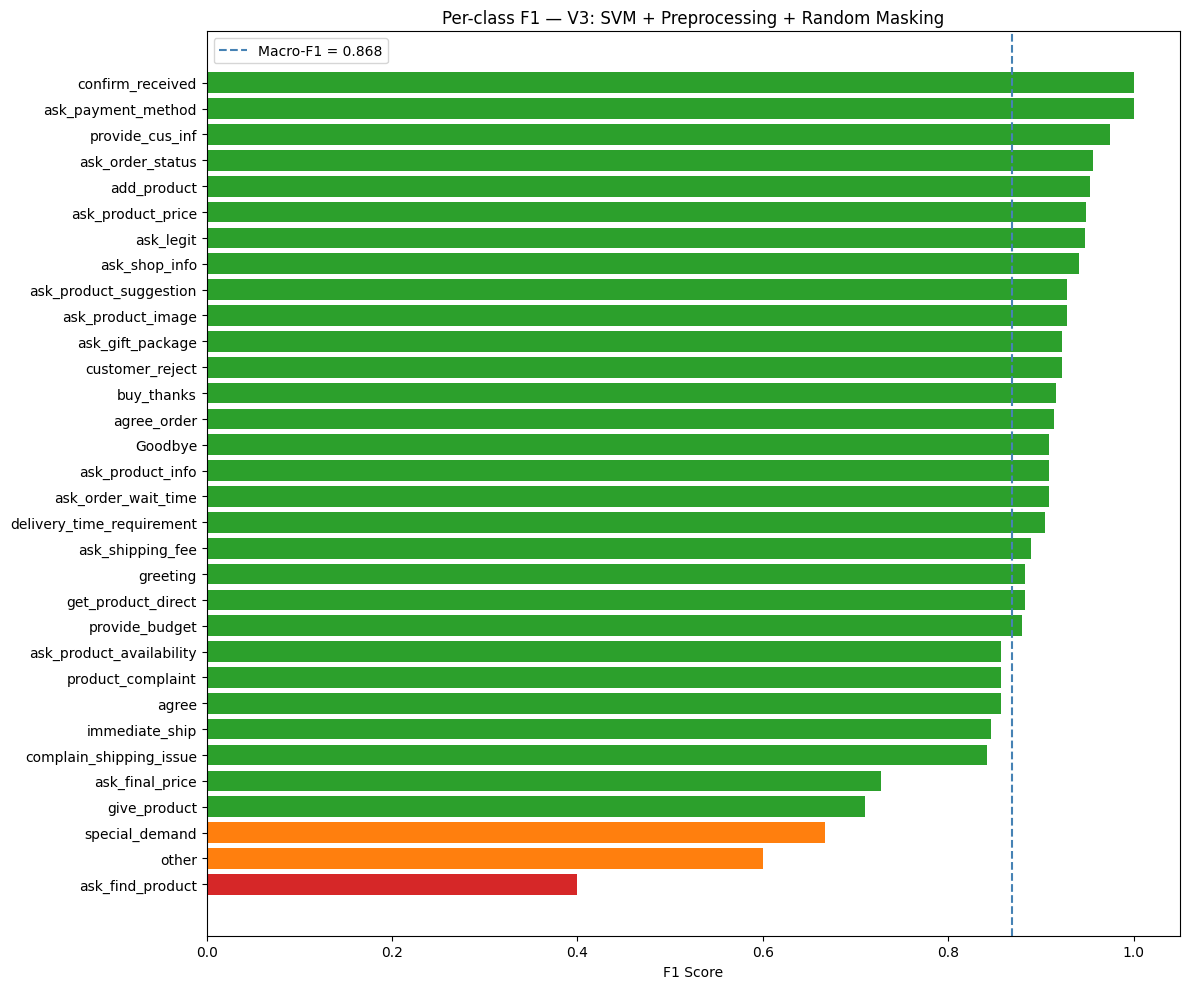

In [12]:
per_class_f1 = f1_score(y_test, y_pred_test, average=None, zero_division=0)
df_f1 = pd.DataFrame({'Label': mlb.classes_, 'F1': per_class_f1}).sort_values('F1', ascending=True)

colors = ['#d62728' if f < 0.5 else '#ff7f0e' if f < 0.7 else '#2ca02c' for f in df_f1['F1']]

plt.figure(figsize=(12, 10))
plt.barh(df_f1['Label'], df_f1['F1'], color=colors)
plt.axvline(macro_f1, color='steelblue', linestyle='--', linewidth=1.5,
            label=f'Macro-F1 = {macro_f1:.3f}')
plt.xlabel('F1 Score')
plt.title('Per-class F1 — V3: SVM + Preprocessing + Random Masking')
plt.legend()
plt.tight_layout()
plt.savefig('results/v3_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 7b. Learning Curve

     10% ( 875) — Train: 0.9973  Val: 0.7019
     20% (1751) — Train: 0.9820  Val: 0.8116
     30% (2627) — Train: 0.9909  Val: 0.8448
     40% (3503) — Train: 0.9897  Val: 0.8593
     50% (4379) — Train: 0.9931  Val: 0.8596
     60% (5254) — Train: 0.9931  Val: 0.8533
     70% (6130) — Train: 0.9927  Val: 0.8612
     80% (7006) — Train: 0.9929  Val: 0.8570
     90% (7882) — Train: 0.9918  Val: 0.8542
    100% (8758) — Train: 0.9919  Val: 0.8526


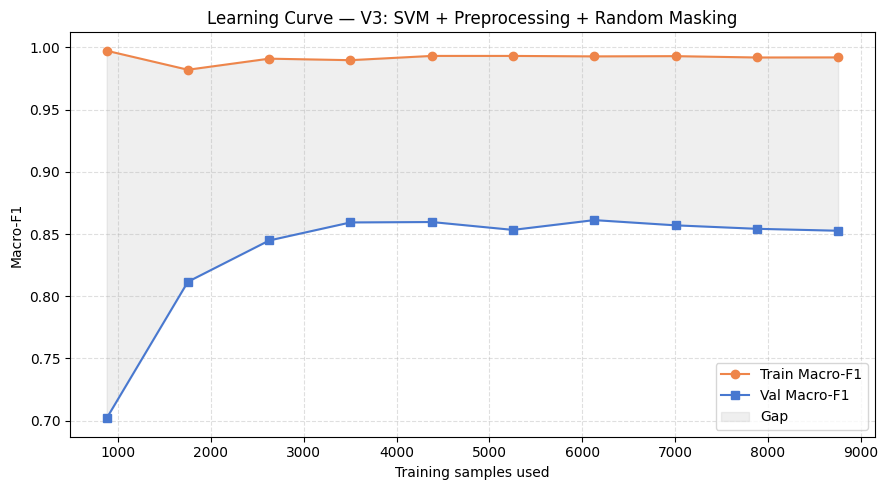


Final gap (Train - Val): +0.1393


In [13]:
fractions   = np.linspace(0.1, 1.0, 10)
train_f1s, val_f1s, train_sizes = [], [], []
n_total = X_train_feat.shape[0]

for frac in fractions:
    n = max(1, int(n_total * frac))
    clf = OneVsRestClassifier(
        LinearSVC(C=best_c, class_weight='balanced', max_iter=2000), n_jobs=-1
    )
    clf.fit(X_train_feat[:n], y_masked[:n])
    train_f1s.append(f1_score(y_masked[:n], clf.predict(X_train_feat[:n]), average='macro', zero_division=0))
    val_f1s.append(  f1_score(y_val,        clf.predict(X_val_feat),       average='macro', zero_division=0))
    train_sizes.append(n)
    print(f'  {frac*100:5.0f}% ({n:4d}) — Train: {train_f1s[-1]:.4f}  Val: {val_f1s[-1]:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_f1s, 'o-', color='#ee854a', label='Train Macro-F1')
ax.plot(train_sizes, val_f1s,   's-', color='#4878d0', label='Val Macro-F1')
ax.fill_between(train_sizes, train_f1s, val_f1s, alpha=0.12, color='gray', label='Gap')
ax.set_xlabel('Training samples used')
ax.set_ylabel('Macro-F1')
ax.set_title('Learning Curve — V3: SVM + Preprocessing + Random Masking')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('results/v3_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFinal gap (Train - Val): {train_f1s[-1] - val_f1s[-1]:+.4f}')

## 8. Save Model and Results

In [14]:
joblib.dump(final_model, 'results/v3_model.joblib')
joblib.dump(tfidf_word,  'results/v3_tfidf_word.joblib')
joblib.dump(tfidf_char,  'results/v3_tfidf_char.joblib')

metrics = {
    'approach'        : 'SVM + Preprocessing + Random Masking (V3)',
    'best_C'          : best_c,
    'mask_prob'       : MASK_PROB,
    'macro_f1'        : round(macro_f1,   4),
    'micro_f1'        : round(micro_f1,   4),
    'hamming_loss'    : round(h_loss,     4),
    'subset_accuracy' : round(subset_acc, 4),
    'per_class_f1'    : {k: round(float(v), 4) for k, v in zip(mlb.classes_, per_class_f1)}
}

with open('results/v3_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print('Saved to approach1/results/: v3_model.joblib, v3_tfidf_*.joblib, v3_metrics.json')

Saved to approach1/results/: v3_model.joblib, v3_tfidf_*.joblib, v3_metrics.json


## 9. Test Custom Input

In [15]:
import joblib, json, re, datetime
import numpy as np
import scipy.sparse as sp
from scipy.sparse import hstack

_model      = joblib.load('results/v3_model.joblib')
_tfidf_word = joblib.load('results/v3_tfidf_word.joblib')
_tfidf_char = joblib.load('results/v3_tfidf_char.joblib')
_mlb        = joblib.load('../final_data/mlb.joblib')

_prediction_log = []

def predict(text: str, top_k: int = 3):
    norm = normalize(text)
    feat = hstack([_tfidf_word.transform([norm]), _tfidf_char.transform([norm]), handcrafted_features([norm])])
    predicted = _mlb.inverse_transform(_model.predict(feat))[0]
    scores    = _model.decision_function(feat)[0]
    ranked    = sorted(zip(_mlb.classes_, scores), key=lambda x: -x[1])

    _prediction_log.append({
        'timestamp' : datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'input'     : text,
        'normalized': norm,
        'predicted' : list(predicted),
        'top_scores': {label: round(float(s), 4) for label, s in ranked[:top_k]},
    })

    print(f'Input     : {text}')
    print(f'Normalized: {norm}')
    print(f'Predicted : {list(predicted) if predicted else "[none above threshold]"}')
    print(f'Top {top_k} scores:')
    for label, score in ranked[:top_k]:
        marker = ' <--' if label in predicted else ''
        print(f'  {label:<35} {score:+.3f}{marker}')

print('predict() ready.')

predict() ready.


In [22]:
# ── Change this text and re-run ───────────────────────────────────────────────────
predict('ship về ngõ 20 Cát Linh mất tầm bao nhiêu shop nhỉ')

Input     : ship về ngõ 20 Cát Linh mất tầm bao nhiêu shop nhỉ
Normalized: ship về ngõ 20 cát linh mất tầm bao nhiêu shop nhỉ
Predicted : ['ask_order_wait_time']
Top 3 scores:
  ask_order_wait_time                 +0.310 <--
  ask_shipping_fee                    -0.512
  ask_product_info                    -0.811


In [17]:
samples = ['shop ơi', 'bao g có hàng thế ạ', 'cho e đặt màu xanh với ạ', 'giá con này bao nhiêu vậy shop']
for text in samples:
    print('-' * 55)
    predict(text, top_k=2)
print('-' * 55)

-------------------------------------------------------
Input     : shop ơi
Normalized: shop ơi
Predicted : ['greeting']
Top 2 scores:
  greeting                            +1.159 <--
  customer_reject                     -0.953
-------------------------------------------------------
Input     : bao g có hàng thế ạ
Normalized: bao g có hàng thế ạ
Predicted : ['ask_order_wait_time']
Top 2 scores:
  ask_order_wait_time                 +1.030 <--
  ask_order_status                    -0.464
-------------------------------------------------------
Input     : cho e đặt màu xanh với ạ
Normalized: cho em đặt màu xanh với ạ
Predicted : ['agree_order']
Top 2 scores:
  agree_order                         +1.305 <--
  ask_product_image                   -0.504
-------------------------------------------------------
Input     : giá con này bao nhiêu vậy shop
Normalized: giá con này bao nhiêu vậy shop
Predicted : ['ask_product_price']
Top 2 scores:
  ask_product_price                   +2.444 <--
 

## 10. Prediction History Log

In [18]:
def show_log(n=None):
    entries = _prediction_log if n is None else _prediction_log[-n:]
    if not entries:
        print('Log is empty — run predict() first.')
        return
    print(f'{"#":<4} {"Timestamp":<20} {"Input":<40} {"Predicted"}')
    print('-' * 100)
    for i, e in enumerate(entries):
        idx   = len(_prediction_log) - len(entries) + i + 1
        inp   = e['input'][:38] + '..' if len(e['input']) > 40 else e['input']
        preds = ', '.join(e['predicted']) if e['predicted'] else '[none]'
        print(f'{idx:<4} {e["timestamp"]:<20} {inp:<40} {preds}')
    print(f'\nTotal entries: {len(_prediction_log)}')

show_log()

#    Timestamp            Input                                    Predicted
----------------------------------------------------------------------------------------------------
1    2026-06-07 22:37:54  sốp ơi còn hàng con ferrari k ạ          ask_product_availability
2    2026-06-07 22:37:54  shop ơi                                  greeting
3    2026-06-07 22:37:54  bao g có hàng thế ạ                      ask_order_wait_time
4    2026-06-07 22:37:54  cho e đặt màu xanh với ạ                 agree_order
5    2026-06-07 22:37:54  giá con này bao nhiêu vậy shop           ask_product_price

Total entries: 5


In [19]:
LOG_PATH = 'results/v3_prediction_log.jsonl'

def save_log(path=LOG_PATH, mode='append'):
    if not _prediction_log:
        print('Nothing to save.')
        return
    if mode == 'append':
        existing = set()
        try:
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    e = json.loads(line)
                    existing.add((e['timestamp'], e['input']))
        except FileNotFoundError:
            pass
        new = [e for e in _prediction_log if (e['timestamp'], e['input']) not in existing]
        with open(path, 'a', encoding='utf-8') as f:
            for e in new:
                json.dump(e, f, ensure_ascii=False); f.write('\n')
        print(f'Appended {len(new)} entries → {path}')
    else:
        with open(path, 'w', encoding='utf-8') as f:
            for e in _prediction_log:
                json.dump(e, f, ensure_ascii=False); f.write('\n')
        print(f'Saved {len(_prediction_log)} entries → {path}')

def clear_log():
    count = len(_prediction_log)
    _prediction_log.clear()
    print(f'Cleared {count} entries.')

print('save_log() / clear_log() ready.')

save_log() / clear_log() ready.
